In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shrutimehta/zomato-restaurants-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\shrutimehta\zomato-restaurants-data\versions\2


In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [169]:
df = pd.read_csv(r"C:\Users\USER\.cache\kagglehub\datasets\shrutimehta\zomato-restaurants-data\versions\2\zomato.csv", encoding="latin1")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [170]:
cc = pd.read_excel(r"C:\Users\USER\.cache\kagglehub\datasets\shrutimehta\zomato-restaurants-data\versions\2\Country-Code.xlsx") #, encoding="latin1")
cc

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


## Inspect dataset

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [172]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [173]:
def mapper(df, key, col):
    return dict(zip(df[key], df[col]))

In [174]:
# map code numbers to name
mapped_country = mapper( cc , "Country Code", "Country")

df["Country Name"] = df["Country Code"].map(mapped_country)

In [175]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country Name            0
dtype: int64

In [176]:
df.duplicated().sum()

np.int64(0)

## Exploratory data analysis

### Restaurant Distribution

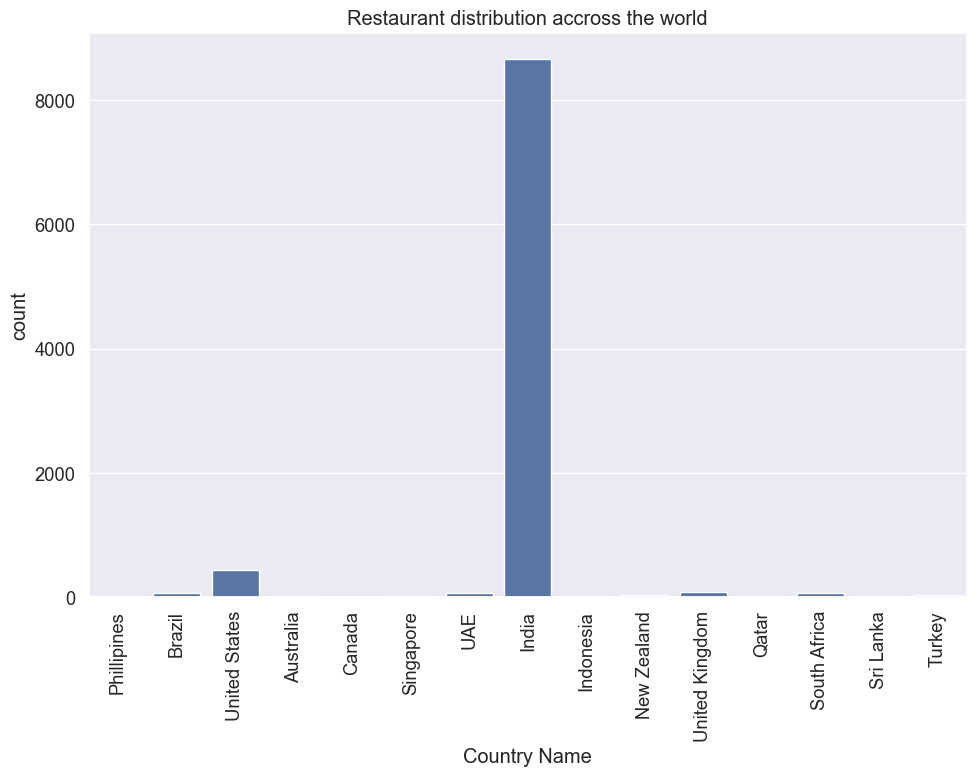

In [177]:
plt.figure(figsize=(10,8))

sns.countplot(data=df , x="Country Name")
plt.title("Restaurant distribution accross the world")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


India contains the highest number of restaurants in the dataset, significantly exceeding the counts observed in the United States and the United Kingdom.

In [178]:
import plotly.express as px

country_iso3 = {
    'Australia': 'AUS',
    'Brazil': 'BRA',
    'Canada': 'CAN',
    'India': 'IND',
    'Indonesia': 'IDN',
    'New Zealand': 'NZL',
    'Phillipines': 'PHL',
    'Qatar': 'QAT',
    'Singapore': 'SGP',
    'South Africa': 'ZAF',
    'Sri Lanka': 'LKA',
    'Turkey': 'TUR',
    'UAE': 'ARE',
    'United Kingdom': 'GBR',
    'United States': 'USA'
}

top_df = (
    df.groupby('Country Name')['City']
    .value_counts()
    .groupby(level=0)
    .head(1)
    .reset_index(name='Count')
)
top_df['iso_alpha'] = top_df['Country Name'].map(country_iso3)

fig = px.choropleth(
    top_df,
    locations='iso_alpha',
    color='Count',
    hover_name='City',
    hover_data={'Country Name': True, 'iso_alpha': False},
    title='Most Frequent City per Country'
)

fig.update_layout(width=1200, height=600)
fig.show()


### Cost Distribution by Country

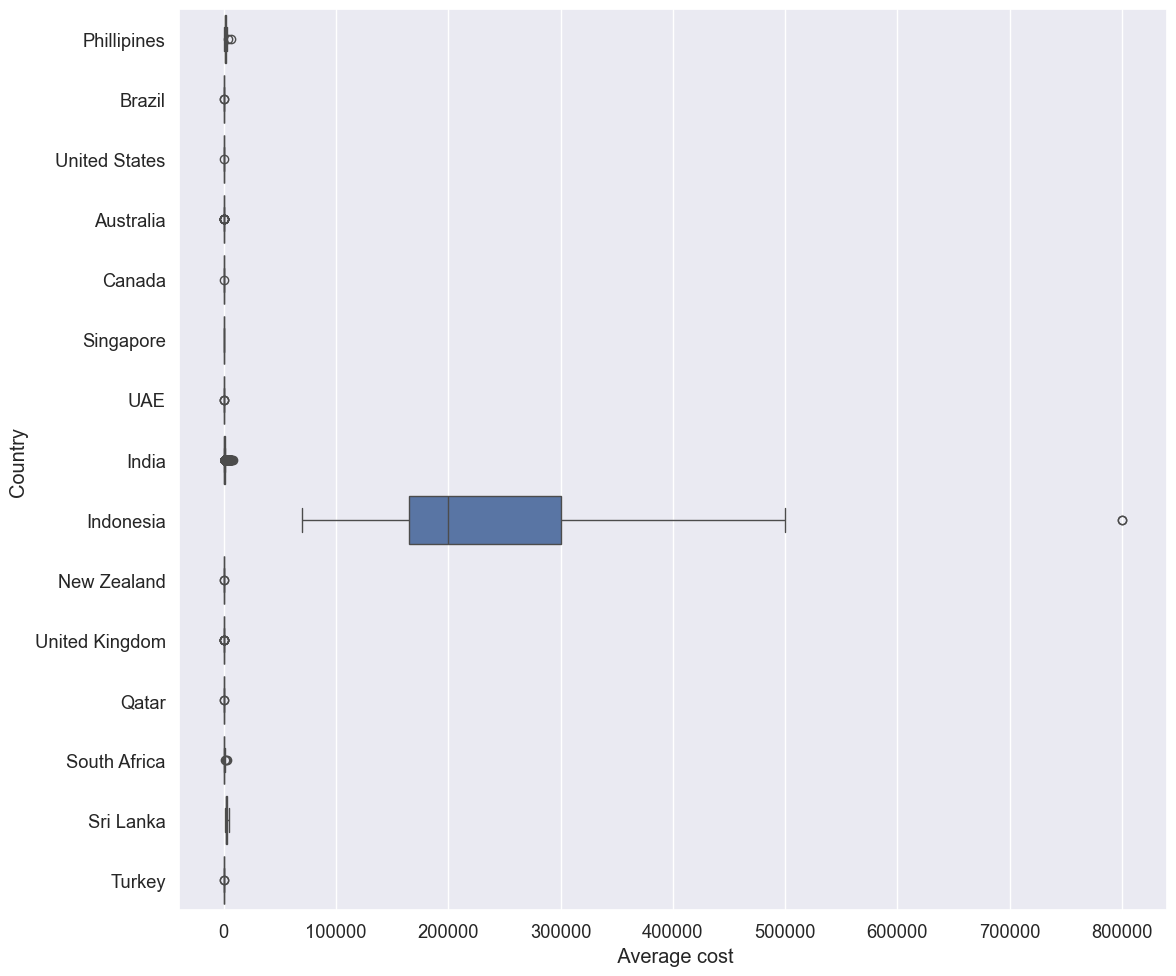

In [179]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df , x="Average Cost for two", y="Country Name")
plt.xlabel(" Average cost")
plt.ylabel("Country ")
plt.tight_layout()
plt.show()

To standardize comparisons across countries, a new feature is created by converting all costs into USD.

In [180]:
# Exchange rate per USD
exchange_2018 = {
    "Botswana Pula(P)": 10.2,
    "Brazilian Real(R$)": 3.65,
    "Dollar($)": 1,
    "Emirati Diram(AED)": 3.67,
    "Indian Rupees(Rs.)": 68,
    "Indonesian Rupiah(IDR)": 14200,
    "NewZealand($)": 1.45,
    "Pounds(\x8c£)": 0.75,
    "Qatari Rial(QR)": 3.64,
    "Rand(R)": 13.2,
    "Sri Lankan Rupee(LKR)": 160,
    "Turkish Lira(TL)": 4.8
}


df["exchange_rate_2018"] = df["Currency"].map(exchange_2018)

In [181]:
# Generate new column 
df["Average_cost_USD"] = round(df["Average Cost for two"] / df["exchange_rate_2018"])

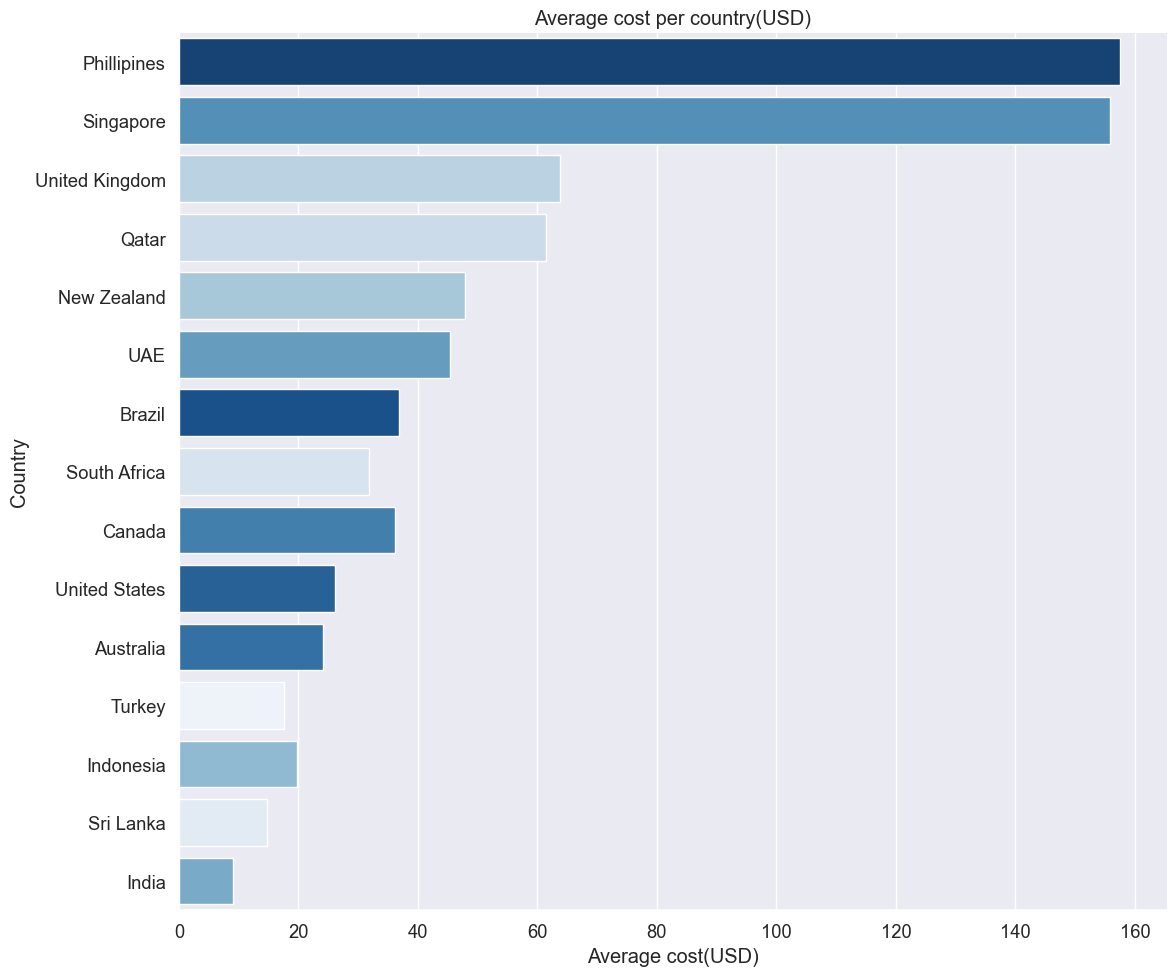

In [182]:
order = df.groupby("Country Name")["Average_cost_USD"].median().sort_values(ascending=False).index

plt.figure(figsize=(12,10))

sns.barplot(data=df , x="Average_cost_USD", y="Country Name", order=order, errorbar=None, hue="Country Name", palette = "Blues_r")
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.title("Average cost per country(USD)")
plt.xlabel("Average cost(USD)")
plt.ylabel("Country")

sns.despine()
plt.tight_layout()
plt.show()          


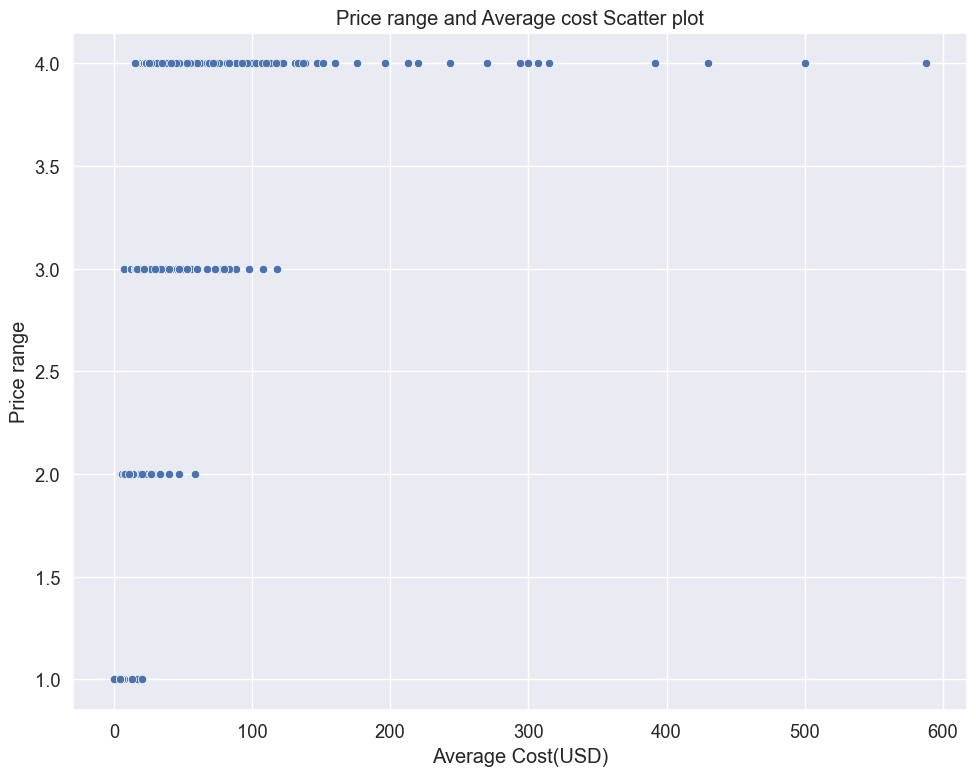

In [183]:
plt.figure(figsize=(10,8))
sns.set_theme(style="darkgrid", font_scale=1.2)

sns.scatterplot(data=df , x="Average_cost_USD", y="Price range" )
plt.title("Price range and Average cost Scatter plot")
plt.xlabel("Average Cost(USD)")
plt.ylabel("Price range")  
plt.tight_layout()
plt.show()

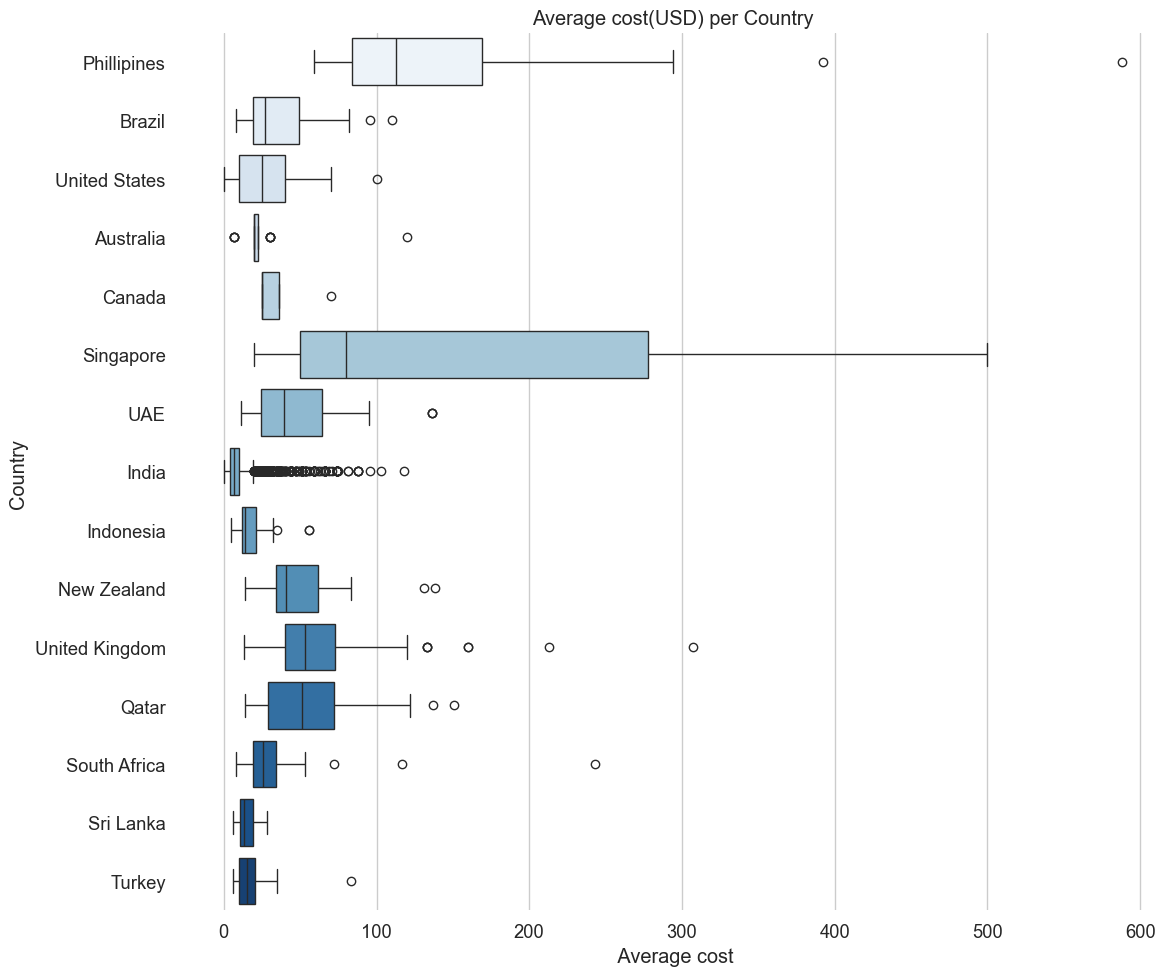

In [184]:
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid", font_scale=1.2)
    
sns.boxplot(data=df , x="Average_cost_USD", y="Country Name", hue="Country Name", palette="Blues")
plt.title( "Average cost(USD) per Country" )
plt.xlabel(" Average cost")
plt.ylabel("Country ")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

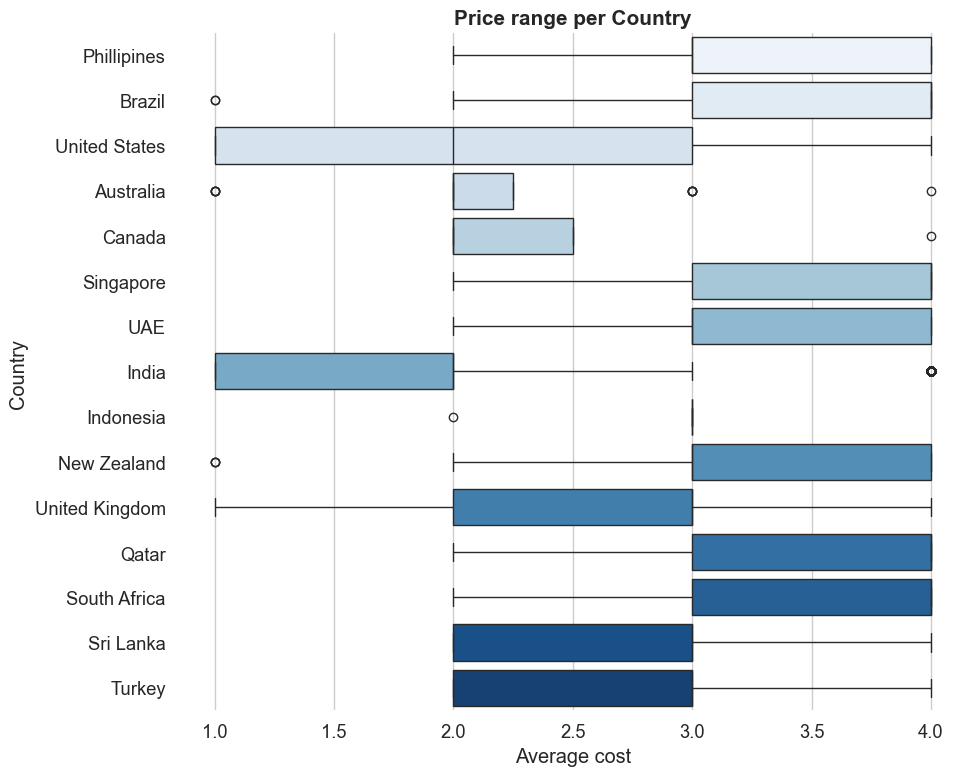

In [185]:
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid", font_scale=1.2)

sns.boxplot(data=df , x="Price range", y="Country Name", hue="Country Name", palette="Blues")
plt.title("Price range per Country", fontsize=15, weight="bold")
plt.xlabel("Average cost")
plt.ylabel("Country ")

sns.despine(left=True , bottom=True)
plt.tight_layout()
plt.show()

Restaurants in Singapore and the Philippines tend to be more expensive, as shown by their higher average costs and the fact that most restaurant prices fall within the higher price‑range categories.

### Rating distribution

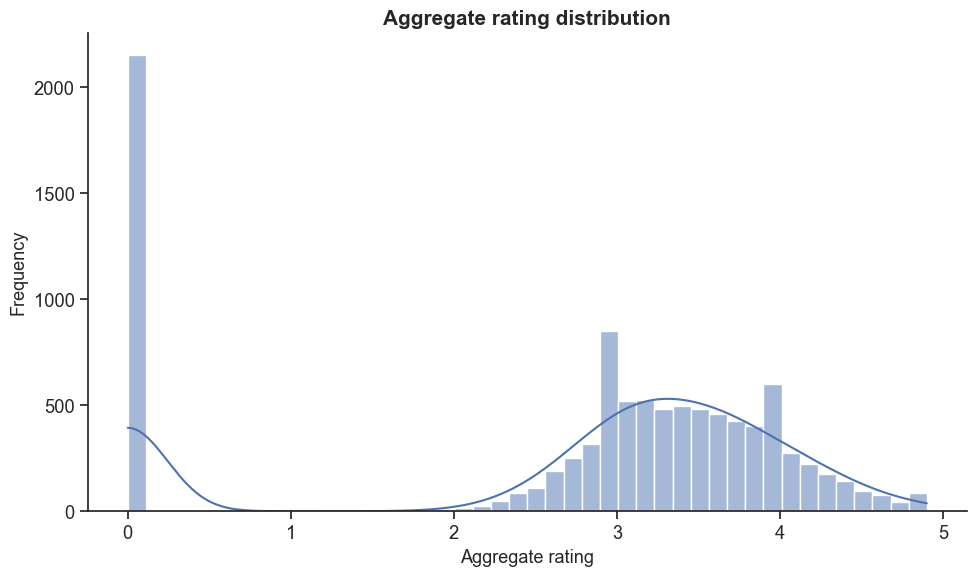

In [186]:
plt.figure(figsize=(10,6))
sns.set_style("ticks")

sns.histplot( data=df , x="Aggregate rating" , bins="fd" , kde=True)
plt.title("Aggregate rating distribution", fontsize=15, weight="bold")
plt.xlabel("Aggregate rating", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

The raw ratings are zero-inflated and right-skewed. Many restaurants have no ratings (or zero), creating a large spike at the lower end. Among rated restaurants, most scores fall between 3.0 and 4.0, with fewer high ratings above 4.0. This indicates a mix of missing data and moderately positive user reviews.

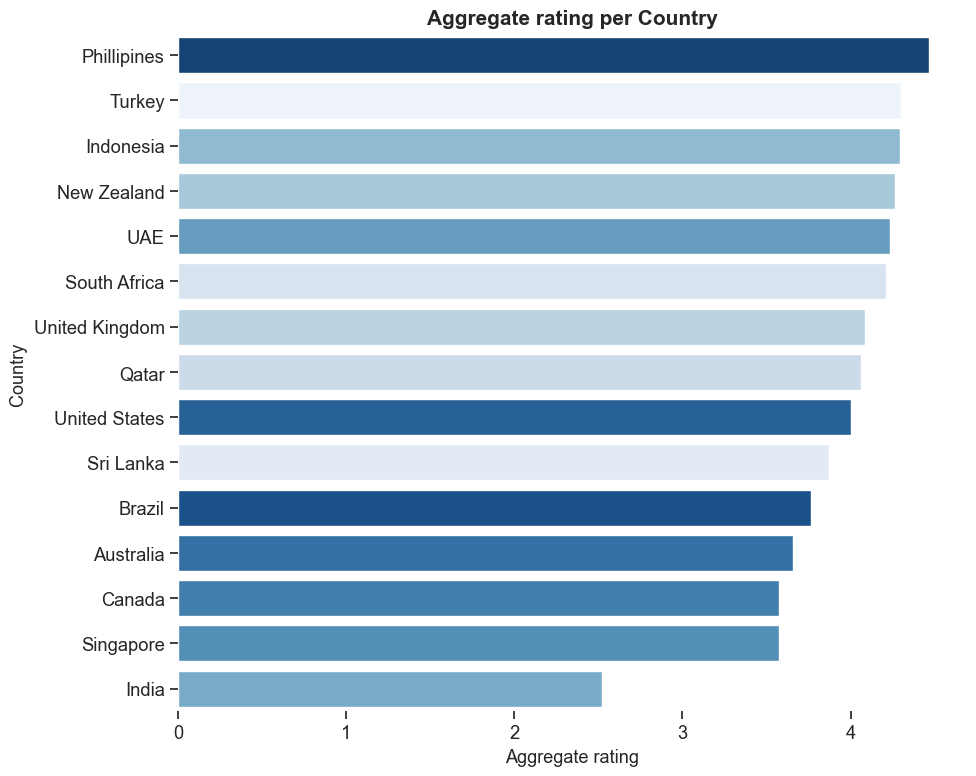

In [187]:
order = df.groupby("Country Name")["Aggregate rating"].mean().sort_values(ascending = False).index

plt.figure(figsize=(10, 8))
sns.barplot(data=df , x="Aggregate rating", y="Country Name", order=order , errorbar=None, hue="Country Name", palette = "Blues_r")
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.title("Aggregate rating per Country", fontsize=15, weight="bold")
plt.xlabel("Aggregate rating", fontsize=13)
plt.ylabel("Country ", fontsize=13)

sns.despine(left=True , bottom=True)
plt.tight_layout()
plt.show()

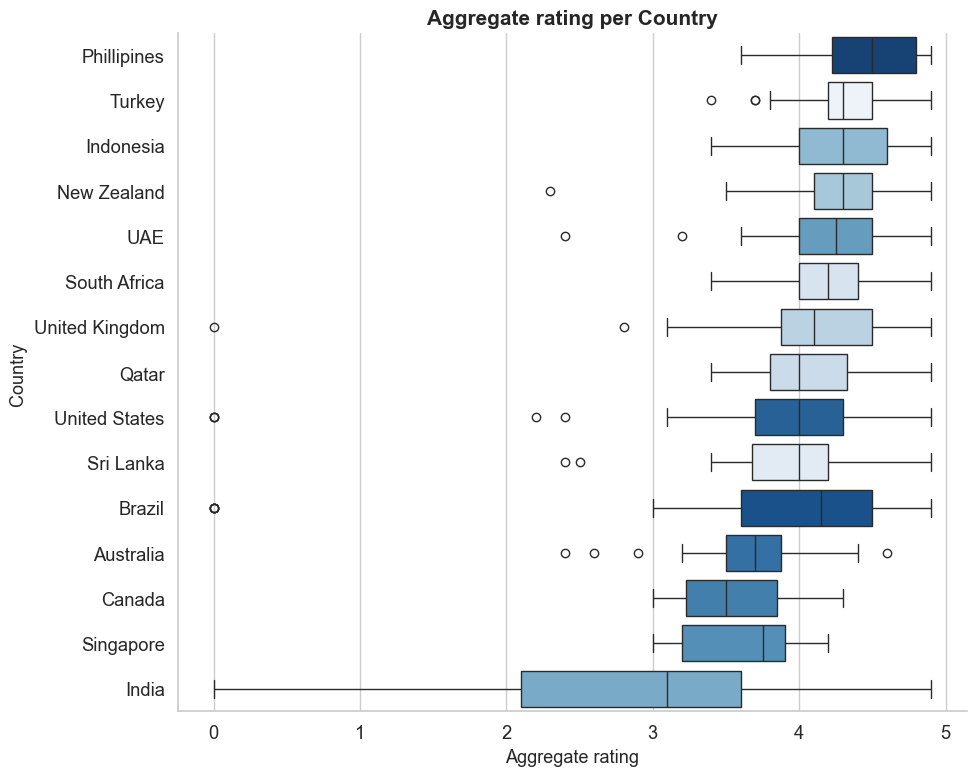

In [188]:
order = df.groupby("Country Name")["Aggregate rating"].mean().sort_values(ascending = False).index

plt.figure(figsize=(10, 8))
sns.boxplot(data=df , x="Aggregate rating", y="Country Name", order=order , hue="Country Name", palette = "Blues_r")
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.title("Aggregate rating per Country", fontsize=15, weight="bold")
plt.xlabel("Aggregate rating", fontsize=13)
plt.ylabel("Country ", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

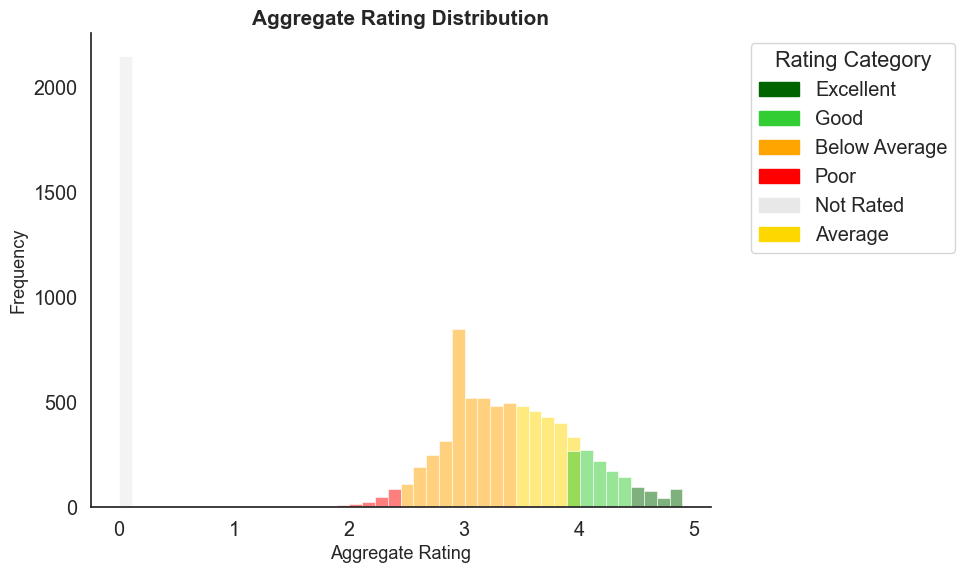

In [189]:
import matplotlib.patches as mpatches

custom_colors = {
    "Dark Green": "#006400",
    "Green": "#32CD32",
    "Orange": "#FFA500",
    "Red": "#FF0000",
    "White": "#E8E8E8",
    "Yellow": "#FFD700"
}

label_map = {
    "Dark Green": "Excellent",
    "Green": "Good",
    "Yellow": "Average",
    "Orange": "Below Average",
    "Red": "Poor",
    "White": "Not Rated"
}

plt.figure(figsize=(10,6))
sns.set_theme(style="white", font_scale=1.3)

ax = sns.histplot(
    data=df,
    x="Aggregate rating",
    bins="fd",
    hue="Rating color",
    palette=custom_colors,
    alpha=0.50,
    linewidth=0.4,
    legend=False   # IMPORTANT: turn off automatic legend
)


handles = [
    mpatches.Patch(color=custom_colors[k], label=label_map[k])
    for k in custom_colors.keys()
]

ax.legend(
    handles=handles,
    title="Rating Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("Aggregate Rating Distribution", fontsize=15, weight="bold")
plt.xlabel("Aggregate Rating", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

In [190]:
# Apply Bayesian weighting to generate more reliable ratings based on customer vote volume

# City-level average rating
city_C = df.groupby("City")["Aggregate rating"].transform("mean")

# City-level median votes
city_m = df.groupby("City")["Votes"].transform("median")

# Bayesian weighted rating per restaurant within its city
df["bayesian_rating"] = round(
    (
        df["Votes"] * df["Aggregate rating"] +
        city_m * city_C
    ) /
    (df["Votes"] + city_m),
    1)

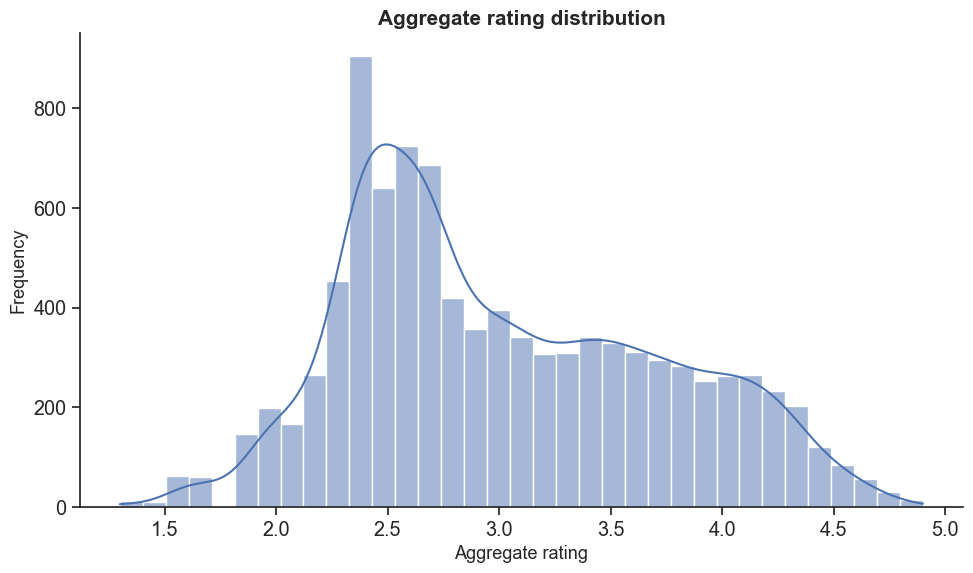

In [191]:
plt.figure(figsize=(10,6))
sns.set_style("ticks")

sns.histplot( data=df , x="bayesian_rating" , bins="fd" , kde=True)
plt.title("Aggregate rating distribution", fontsize=15, weight="bold")
plt.xlabel("Aggregate rating", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

The Bayesian rating reduces noise from low-vote restaurants by shrinking their scores toward the city average. Restaurants with many votes stay close to their original ratings, while low-information ones are adjusted. This produces a more stable and confidence-weighted distribution, but with stronger central clustering.

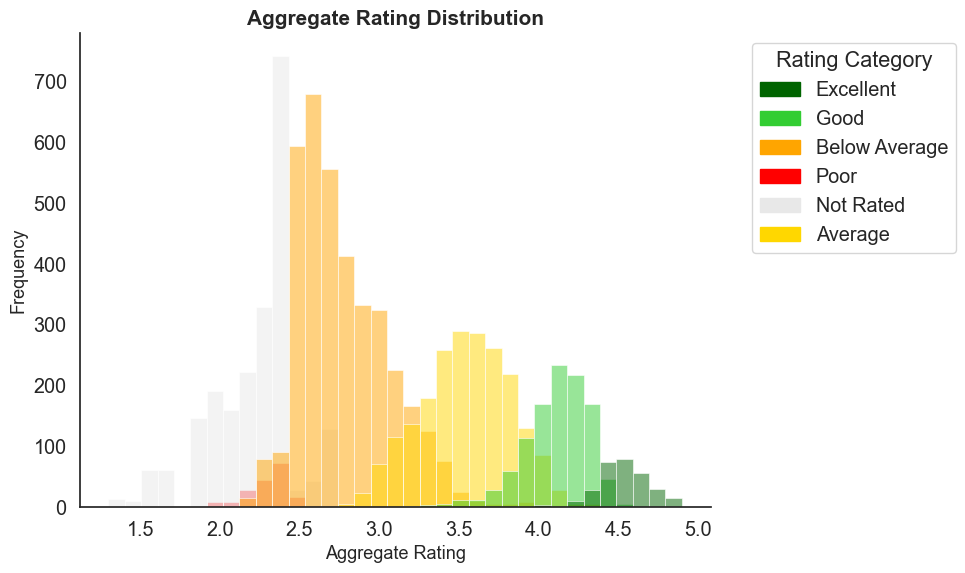

In [192]:
custom_colors = {
    "Dark Green": "#006400",
    "Green": "#32CD32",
    "Orange": "#FFA500",
    "Red": "#FF0000",
    "White": "#E8E8E8",
    "Yellow": "#FFD700"
}

label_map = {
    "Dark Green": "Excellent",
    "Green": "Good",
    "Yellow": "Average",
    "Orange": "Below Average",
    "Red": "Poor",
    "White": "Not Rated"
}

plt.figure(figsize=(10,6))
sns.set_theme(style="white", font_scale=1.3)

ax = sns.histplot(
    data=df,
    x="bayesian_rating",
    bins="fd",
    hue="Rating color",
    palette=custom_colors,
    alpha=0.50,
    linewidth=0.4,
    legend=False   # IMPORTANT: turn off automatic legend
)


handles = [
    mpatches.Patch(color=custom_colors[k], label=label_map[k])
    for k in custom_colors.keys()
]

ax.legend(
    handles=handles,
    title="Rating Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("Aggregate Rating Distribution", fontsize=15, weight="bold")
plt.xlabel("Aggregate Rating", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

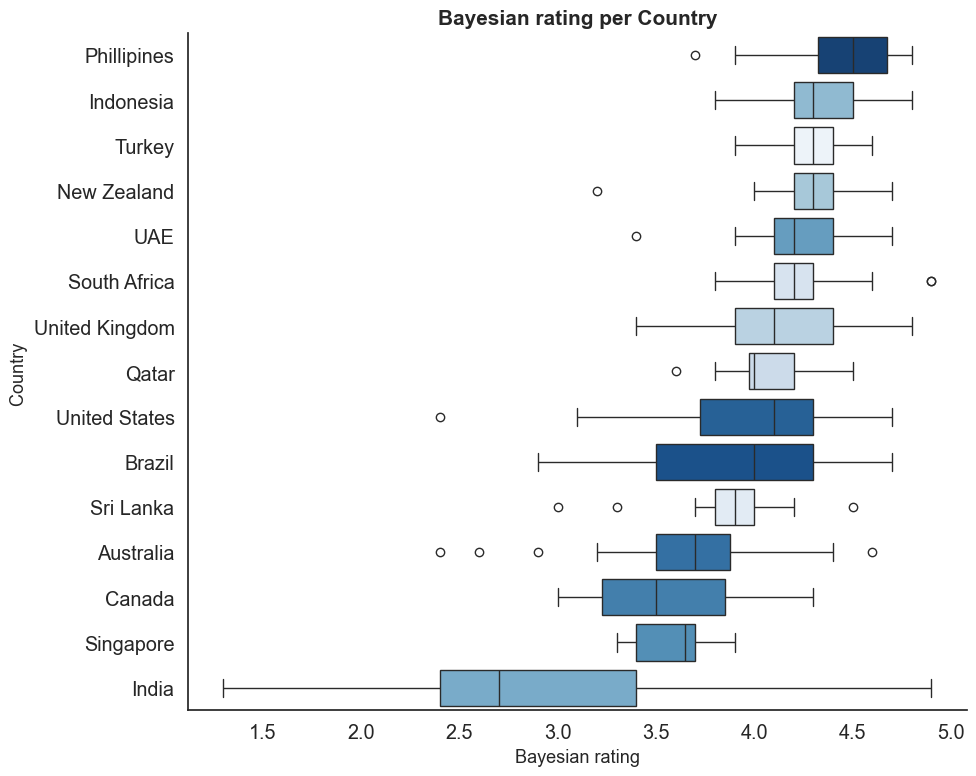

In [193]:
order = df.groupby("Country Name")["bayesian_rating"].mean().sort_values(ascending = False).index

plt.figure(figsize=(10, 8))
sns.boxplot(data=df , x="bayesian_rating", y="Country Name", order=order , hue="Country Name", palette = "Blues_r")
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.title("Bayesian rating per Country", fontsize=15, weight="bold")
plt.xlabel("Bayesian rating", fontsize=13)
plt.ylabel("Country ", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

## Distribution of Votes

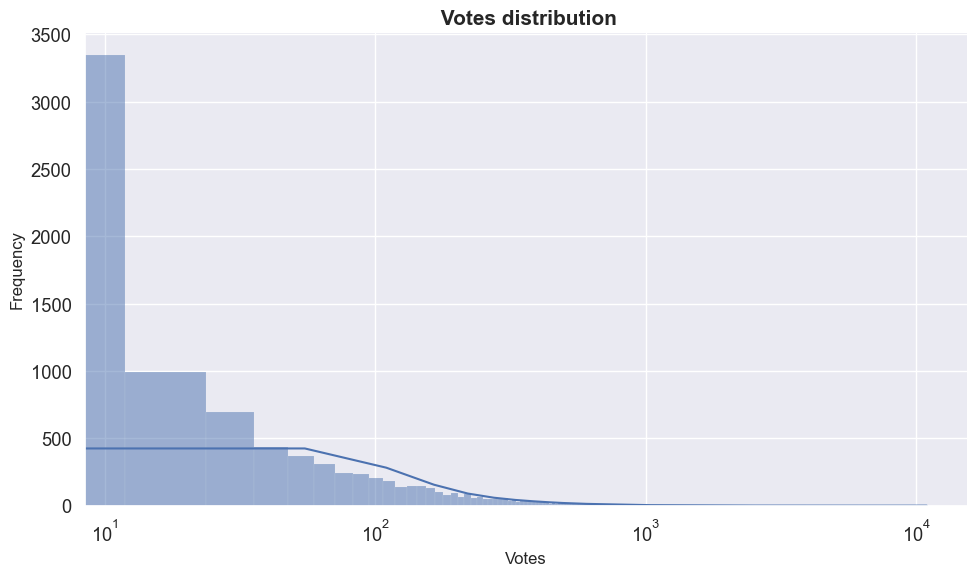

In [194]:
sns.set_theme(style="darkgrid", font_scale=1.2)
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='Votes', bins="fd", kde=True)
plt.xscale("log")
plt.title(" Votes distribution",  fontsize=15, weight="bold")
plt.xlabel( "Votes",  fontsize=12)
plt.ylabel("Frequency", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

In [195]:
agg_rat_0= df[df["Aggregate rating"]==0]
print("Aggregated 0:" , len(agg_rat_0))
agg_rat_vot_0= df[(df["Aggregate rating"]==0) &  (df["Votes"]==0 )]
print("Aggregated and Voted 0:" ,len(agg_rat_vot_0))

Aggregated 0: 2148
Aggregated and Voted 0: 1094


The majority of ratings receive very few votes, whereas a small number receive exceptionally high vote counts.

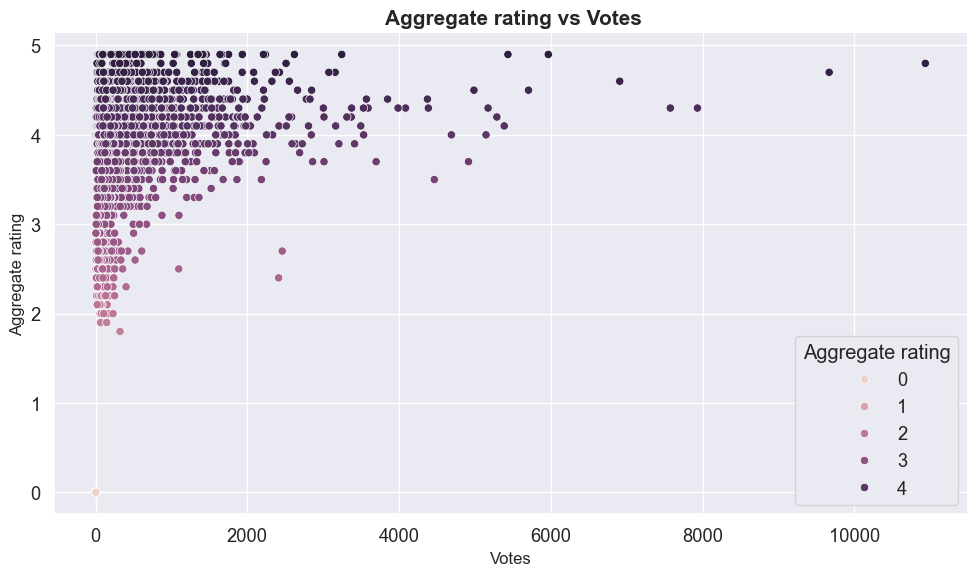

In [196]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Votes', y='Aggregate rating', hue="Aggregate rating")
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.title(" Aggregate rating vs Votes",  fontsize=15, weight="bold")
plt.xlabel( "Votes",  fontsize=12)
plt.ylabel("Aggregate rating", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

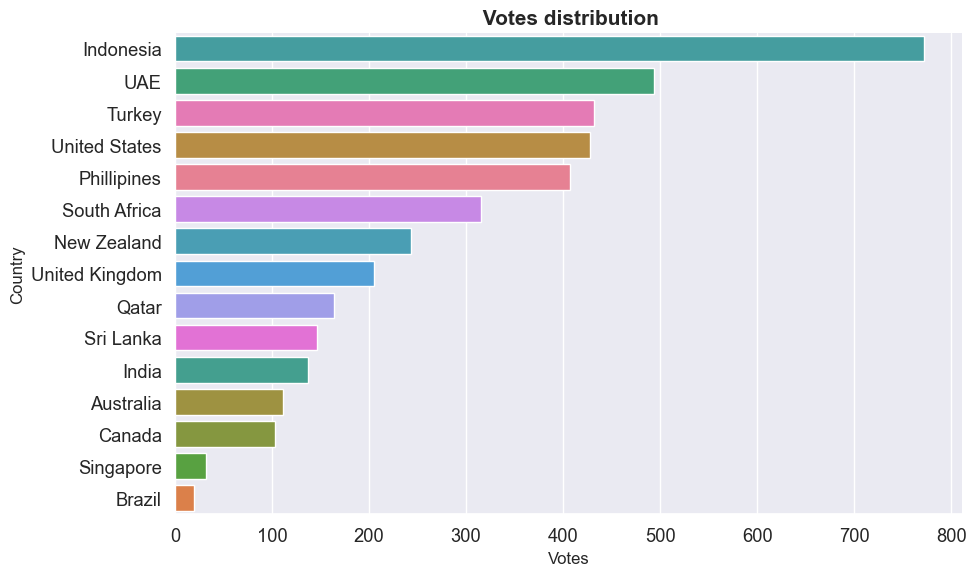

In [197]:
order = df.groupby("Country Name")["Votes"].mean().sort_values(ascending=False).index

sns.set_theme(style="darkgrid", font_scale=1.2)
plt.figure(figsize=(10,6))

sns.barplot(data=df, x='Votes', y="Country Name", order=order, errorbar=None, hue="Country Name")

plt.title(" Votes distribution",  fontsize=15, weight="bold")
plt.xlabel( "Votes",  fontsize=12)
plt.ylabel("Country", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

In [198]:
df[["Aggregate rating", "Votes"]].corr()

,Aggregate rating,Votes
Aggregate rating,1.000000,0.313691
Votes,0.313691,1.000000


In [199]:
df[["Aggregate rating", "Votes"]].corr(method="spearman")

,Aggregate rating,Votes
Aggregate rating,1.000000,0.846247
Votes,0.846247,1.000000


In [200]:
df['log_votes'] = np.log1p(df['Votes'])

df[['Aggregate rating', 'log_votes']].corr()

,Aggregate rating,log_votes
Aggregate rating,1.000000,0.848357
log_votes,0.848357,1.000000


In [201]:
df_rated = df.loc[df['Votes'] > 0].copy()

df_rated['log_votes'] = np.log1p(df_rated['Votes'])

df_rated[['Aggregate rating', 'log_votes']].corr(method='spearman')


,Aggregate rating,log_votes
Aggregate rating,1.000000,0.785801
log_votes,0.785801,1.000000


In [202]:
df_rated = df.loc[(df['Votes'] > 0) & (df['Aggregate rating'] > 0)].copy()

df_rated['log_votes'] = np.log1p(df_rated['Votes'])

df_rated[['Aggregate rating', 'log_votes']].corr(method='spearman')


,Aggregate rating,log_votes
Aggregate rating,1.000000,0.682106
log_votes,0.682106,1.000000


In [203]:
df_rated['Votes'].quantile([0.95, 0.99])

0.95     833.90
0.99    2183.92
Name: Votes, dtype: float64

## Classification


In [204]:
df_model = df.copy()

In [205]:
df_model['Primary_Cuisine'] = (
    df_model['Cuisines']
    .fillna('Unknown')
    .str.split(',')
    .str[0]
    .str.strip()  # this on cat boost gave 0.69
)

In [206]:
df_model["popularity"] = df_model["Aggregate rating"] * df_model["log_votes"]

In [207]:
df_model["cuisine_richness"] = df_model["Cuisines"].apply(lambda x: len(str(x).split(","))) 

In [208]:
df_model["Cuisine_List"] = df_model["Cuisines"].apply(lambda x: [c.strip() for c in str(x).split(",")])

In [209]:
from collections import Counter

cuisine_counter = Counter()

for cuisines in df_model["Cuisine_List"]:
    cuisine_counter.update(cuisines)

# Show top 40 most common cuisines
top_cuisines = [c for c, count in cuisine_counter.most_common(40)]
top_cuisines

['North Indian',
 'Chinese',
 'Fast Food',
 'Mughlai',
 'Italian',
 'Bakery',
 'Continental',
 'Cafe',
 'Desserts',
 'South Indian',
 'Street Food',
 'American',
 'Pizza',
 'Mithai',
 'Burger',
 'Thai',
 'Asian',
 'Beverages',
 'Ice Cream',
 'Mexican',
 'Biryani',
 'Seafood',
 'Healthy Food',
 'European',
 'Japanese',
 'Finger Food',
 'Raw Meats',
 'Mediterranean',
 'Salad',
 'Sushi',
 'Indian',
 'Lebanese',
 'Steak',
 'Sandwich',
 'Tea',
 'Tibetan',
 'Breakfast',
 'Bar Food',
 'BBQ',
 'French']

In [210]:
def map_cuisine_category(cuisine):
    c = str(cuisine).lower()

    # Asian cluster
    if any(x in c for x in [
        "chinese", "thai", "japanese", "asian", "tibetan", "sushi"
    ]):
        return "Asian"

    # Indian cluster
    if any(x in c for x in [
        "indian", "mughlai", "biryani", "mithai", "north indian", "south indian"
    ]):
        return "Indian"

    # European cluster
    if any(x in c for x in [
        "italian", "french", "european", "mediterranean"
    ]):
        return "European"

    # American cluster
    if any(x in c for x in [
        "american", "bbq", "bar food", "breakfast"
    ]):
        return "American"

    # Fast food cluster
    if any(x in c for x in [
        "fast food", "burger", "pizza", "sandwich"
    ]):
        return "FastFood"

    # Cafe/Bakery cluster
    if any(x in c for x in [
        "cafe", "bakery", "desserts", "ice cream", "tea", "beverages"
    ]):
        return "CafeBakery"

    # Premium dining cluster
    if any(x in c for x in [
        "seafood", "steak", "raw meats"
    ]):
        return "PremiumDining"

    # Healthy cluster
    if any(x in c for x in [
        "healthy", "salad"
    ]):
        return "Healthy"

    # Middle Eastern cluster
    if any(x in c for x in [
        "lebanese"
    ]):
        return "MiddleEastern"

    # Default
    return "Other"


In [211]:
df_model["Cuisine_Category"] = df_model["Primary_Cuisine"].apply(map_cuisine_category)

In [212]:
# City frequency
freq = df_model['City'].value_counts()

df_model['city_freq'] = df_model['City'].map(freq)

In [213]:
# Primary Cusine Frequency
freq = df_model['Primary_Cuisine'].value_counts()

df_model['cuisine_freq'] = ( df_model['Primary_Cuisine'].map(freq))

In [214]:
# Relative Votes in City
city_avg_votes = df_model.groupby('City')['Votes'].transform('mean')

df_model['relative_votes_city'] = (
    df_model['Votes'] / city_avg_votes
)

In [215]:
import os
import warnings
from sklearn.cluster import KMeans

os.environ['OMP_NUM_THREADS'] = '1'

warnings.filterwarnings(
    'ignore',
    message='KMeans is known to have a memory leak on Windows with MKL.*',
    category=UserWarning
)

df_model['GeoCluster'] = -1

for city in df_model['City'].unique():
    subset = df_model[df_model['City'] == city]
    n_samples = len(subset)

    # Cities with fewer than 4 restaurants are kept in one default cluster.
    if n_samples < 4:
        df_model.loc[subset.index, 'GeoCluster'] = 0
        continue

    # Use approximately one cluster per 200 restaurants, capped between 2 and 10.
    n_clusters = max(2, min(10, n_samples // 200))

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(subset[['Latitude', 'Longitude']])

    df_model.loc[subset.index, 'GeoCluster'] = labels


In [216]:
features = ['City' , 'Primary_Cuisine', 'log_votes', 'Aggregate rating', "popularity", "cuisine_richness", "Cuisine_Category",
             'Has Table booking' , 'Has Online delivery', 'city_freq', 'relative_votes_city', 'cuisine_freq', 'GeoCluster']  

X= df_model[features]
y=df_model["Price range"]

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [218]:
from catboost import CatBoostClassifier

cat_features = ['Primary_Cuisine', 'City', 'Cuisine_Category', 'Has Table booking', 'Has Online delivery']

class_weights = {
    1: 0.538,
    2: 0.767,
    3: 1.697,
    4: 4.073
}

model = CatBoostClassifier(
    loss_function='MultiClass',
    class_weights=class_weights,
    verbose=False
)

model.fit(X_train, y_train, cat_features=cat_features)


CatBoostClassifier(class_weights={1: 0.538, 2: 0.767, 3: 1.697, 4: 4.073}, loss_function='MultiClass', verbose=False)

In [219]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_cb = model.predict(X_test)


print(classification_report(y_test, y_pred_cb))

              precision    recall  f1-score   support

           1       0.82      0.78      0.80       889
           2       0.64      0.61      0.62       623
           3       0.53      0.61      0.57       282
           4       0.48      0.58      0.53       117

    accuracy                           0.69      1911
   macro avg       0.62      0.65      0.63      1911
weighted avg       0.70      0.69      0.69      1911



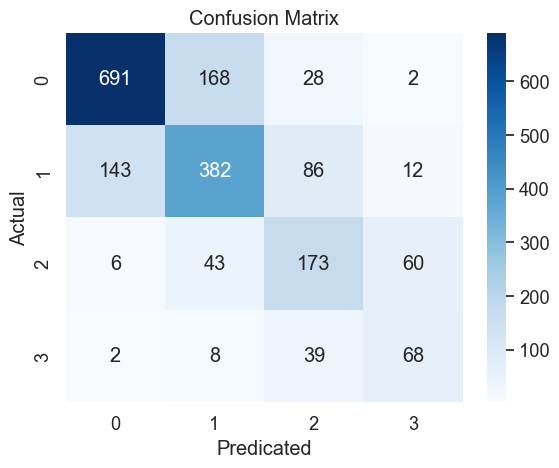

In [220]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_cb)

sns.heatmap(cm , annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicated")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Regression


In [221]:
from catboost import CatBoostRegressor

rg_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=200
)

In [222]:
y = df_model['Average_cost_USD']

In [223]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [224]:
cat_features = [ 'City' , 'Primary_Cuisine',  "Cuisine_Category",  'Has Table booking' , 'Has Online delivery']

In [225]:
rg_model.fit(X_train, y_train, cat_features=cat_features)

y_pred_rg = rg_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_rg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rg))
r2 = r2_score(y_test, y_pred_rg)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')


0:	learn: 17.5666575	total: 132ms	remaining: 2m 11s
200:	learn: 8.6566876	total: 13.1s	remaining: 52s
400:	learn: 7.4555168	total: 25.3s	remaining: 37.8s
600:	learn: 6.6579418	total: 38s	remaining: 25.2s
800:	learn: 6.1639786	total: 50s	remaining: 12.4s
999:	learn: 5.7373143	total: 1m 1s	remaining: 0us
MAE: 4.84
RMSE: 15.33
R2: 0.523


## Summary Percentage Tables


In [226]:
country_distribution = (
    df['Country Name']
    .value_counts()
    .rename_axis('Country')
    .reset_index(name='Restaurant Count')
)

country_distribution['Percentage'] = (
    country_distribution['Restaurant Count'] / len(df) * 100
).round(1)

country_distribution


,Country,Restaurant Count,Percentage
0,India,8652,90.6
1,United States,434,4.5
2,United Kingdom,80,0.8
3,Brazil,60,0.6
4,UAE,60,0.6
5,South Africa,60,0.6
6,New Zealand,40,0.4
7,Turkey,34,0.4
8,Australia,24,0.3
9,Phillipines,22,0.2


In [227]:
price_range_distribution = (
    df['Price range']
    .value_counts()
    .sort_index()
    .rename_axis('Price Range')
    .reset_index(name='Restaurant Count')
)

price_range_distribution['Percentage'] = (
    price_range_distribution['Restaurant Count'] / len(df) * 100
).round(1)

price_range_distribution


,Price Range,Restaurant Count,Percentage
0,1,4444,46.5
1,2,3113,32.6
2,3,1408,14.7
3,4,586,6.1


In [228]:
rating_activity_summary = pd.DataFrame({
    'Metric': [
        'Restaurants with aggregate rating 0',
        'Restaurants with aggregate rating 0 and 0 votes'
    ],
    'Restaurant Count': [
        (df['Aggregate rating'] == 0).sum(),
        ((df['Aggregate rating'] == 0) & (df['Votes'] == 0)).sum()
    ]
})

rating_activity_summary['Percentage'] = (
    rating_activity_summary['Restaurant Count'] / len(df) * 100
).round(1)

rating_activity_summary


,Metric,Restaurant Count,Percentage
0,Restaurants with aggregate rating 0,2148,22.5
1,Restaurants with aggregate rating 0 and 0 votes,1094,11.5


In [229]:
service_availability = pd.concat([
    df['Has Online delivery'].value_counts(normalize=True).mul(100).round(1).rename('Online Delivery (%)'),
    df['Has Table booking'].value_counts(normalize=True).mul(100).round(1).rename('Table Booking (%)')
], axis=1)

service_availability


,Online Delivery (%),Table Booking (%)
No,74.3,87.9
Yes,25.7,12.1


## Overall Findings

This analysis examined 9,551 restaurants from the Zomato dataset across multiple countries. The dataset includes information about restaurant location, cuisine, price range, average cost for two, rating, votes, delivery availability, and table booking availability. The data was first inspected for missing values and duplicates. Only 9 missing values were found in the `Cuisines` column, and no duplicated rows were identified.

The restaurant distribution is highly concentrated in India, which accounts for about 90.6% of the dataset. The United States is the second-largest country group with 4.5%, while all other countries represent much smaller shares. This means the analysis mainly reflects patterns in the Indian restaurant market, with limited representation from other countries.

Most restaurants belong to the lower price categories. Price range 1 represents 46.5% of restaurants, and price range 2 represents 32.6%. Higher-priced restaurants are less common, with price ranges 3 and 4 making up a smaller portion of the dataset. After converting average cost for two into USD, the Philippines and Singapore show some of the highest median restaurant costs, while India remains relatively low-cost.

The rating distribution shows a large number of unrated or zero-rated restaurants. A total of 2,148 restaurants have an aggregate rating of 0, and 1,094 of these also have 0 votes. This indicates that many restaurants have little or no customer rating activity. Among rated restaurants, most ratings fall in the average-to-good range.

Votes are strongly skewed. Most restaurants receive relatively few votes, while a small number receive very high vote counts. The relationship between votes and ratings is positive: restaurants with more customer engagement tend to have higher ratings. The Spearman correlation between aggregate rating and votes is stronger than the Pearson correlation, suggesting that the relationship is monotonic but affected by outliers and non-linear patterns.

Cuisine analysis shows that the most common cuisines include North Indian, Chinese, Fast Food, Mughlai, Italian, Bakery, Continental, Cafe, Desserts, and South Indian. This cuisine distribution also reflects the strong dominance of Indian restaurants in the dataset. Cuisine variety, primary cuisine, and broader cuisine categories were used to better describe restaurant type and positioning.

Service availability is limited across the dataset. Around 74.3% of restaurants do not offer online delivery, and around 87.9% do not offer table booking. These features help describe the operational profile of restaurants and may also relate to price level, restaurant type, and customer engagement.

A classification model was built to predict restaurant price range using location, cuisine, rating, vote, service, and engineered popularity features. The model shows that price range can be partly explained by these restaurant characteristics, especially when categorical features such as city and cuisine are included.

A regression model was also built to predict average cost in USD. The results show that restaurant cost can be estimated from the available features, although prediction remains challenging because prices vary across countries, cities, currencies, restaurant types, and outliers.

Overall, the analysis shows that restaurant pricing and ratings are influenced by geography, cuisine type, customer engagement, and service availability. The main limitation is the strong imbalance toward Indian restaurants, so the findings are most reliable for India-heavy patterns and less representative of a fully global restaurant market.
